# Day 4 — Feature Engineering + Supervised Learning

Google Colab hands-on notebook.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

## Create Sample Data

In [2]:
df = pd.DataFrame({
    "Age": [22, 25, 28, 32, 35, 40, np.nan, 29],
    "Salary": [25000, 32000, 40000, 52000, 60000, 75000, 50000, 45000],
    "City": ["Hyderabad", "Pune", "Delhi", "Hyderabad", "Pune", "Delhi", "Pune", None],
    "Experience": [1, 2, 4, 7, 10, 15, 6, 5],
    "Purchased": [0, 0, 0, 1, 1, 1, 1, 0]
})
df

,Age,Salary,City,Experience,Purchased
0,22.0,25000,Hyderabad,1,0
1,25.0,32000,Pune,2,0
2,28.0,40000,Delhi,4,0
3,32.0,52000,Hyderabad,7,1
4,35.0,60000,Pune,10,1
5,40.0,75000,Delhi,15,1
6,NaN,50000,Pune,6,1
7,29.0,45000,None,5,0


## Feature Creation

In [3]:
df["Salary_per_Year_Exp"] = df["Salary"] / (df["Experience"] + 1)
df

,Age,Salary,City,Experience,Purchased,Salary_per_Year_Exp
0,22.0,25000,Hyderabad,1,0,12500.000000
1,25.0,32000,Pune,2,0,10666.666667
2,28.0,40000,Delhi,4,0,8000.000000
3,32.0,52000,Hyderabad,7,1,6500.000000
4,35.0,60000,Pune,10,1,5454.545455
5,40.0,75000,Delhi,15,1,4687.500000
6,NaN,50000,Pune,6,1,7142.857143
7,29.0,45000,None,5,0,7500.000000


## Missing Value Handling

In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["City"] = df["City"].fillna(df["City"].mode()[0])
df

,Age,Salary,City,Experience,Purchased,Salary_per_Year_Exp
0,22.0,25000,Hyderabad,1,0,12500.000000
1,25.0,32000,Pune,2,0,10666.666667
2,28.0,40000,Delhi,4,0,8000.000000
3,32.0,52000,Hyderabad,7,1,6500.000000
4,35.0,60000,Pune,10,1,5454.545455
5,40.0,75000,Delhi,15,1,4687.500000
6,29.0,50000,Pune,6,1,7142.857143
7,29.0,45000,Pune,5,0,7500.000000


## Standardization

In [5]:
scaler = StandardScaler()
df[["Age_scaled", "Salary_scaled", "Experience_scaled"]] = scaler.fit_transform(
    df[["Age", "Salary", "Experience"]]
)
df.head()

,Age,Salary,City,Experience,Purchased,Salary_per_Year_Exp,Age_scaled,Salary_scaled,Experience_scaled
0,22.0,25000,Hyderabad,1,0,12500.000000,-1.511858,-1.513745,-1.239591
1,25.0,32000,Pune,2,0,10666.666667,-0.944911,-1.040171,-1.003478
2,28.0,40000,Delhi,4,0,8000.000000,-0.377964,-0.498944,-0.531253
3,32.0,52000,Hyderabad,7,1,6500.000000,0.377964,0.312897,0.177084
4,35.0,60000,Pune,10,1,5454.545455,0.944911,0.854125,0.885422


## Normalization

In [6]:
minmax = MinMaxScaler()
df[["Age_norm", "Salary_norm"]] = minmax.fit_transform(df[["Age", "Salary"]])
df.head()

,Age,Salary,City,Experience,Purchased,Salary_per_Year_Exp,Age_scaled,Salary_scaled,Experience_scaled,Age_norm,Salary_norm
0,22.0,25000,Hyderabad,1,0,12500.000000,-1.511858,-1.513745,-1.239591,0.000000,0.00
1,25.0,32000,Pune,2,0,10666.666667,-0.944911,-1.040171,-1.003478,0.166667,0.14
2,28.0,40000,Delhi,4,0,8000.000000,-0.377964,-0.498944,-0.531253,0.333333,0.30
3,32.0,52000,Hyderabad,7,1,6500.000000,0.377964,0.312897,0.177084,0.555556,0.54
4,35.0,60000,Pune,10,1,5454.545455,0.944911,0.854125,0.885422,0.722222,0.70


## One-Hot Encoding

In [7]:
encoded_city = pd.get_dummies(df["City"], prefix="City")
df_encoded = pd.concat([df, encoded_city], axis=1)
df_encoded.head()

,Age,Salary,City,Experience,Purchased,Salary_per_Year_Exp,Age_scaled,Salary_scaled,Experience_scaled,Age_norm,Salary_norm,City_Delhi,City_Hyderabad,City_Pune
0,22.0,25000,Hyderabad,1,0,12500.000000,-1.511858,-1.513745,-1.239591,0.000000,0.00,False,True,False
1,25.0,32000,Pune,2,0,10666.666667,-0.944911,-1.040171,-1.003478,0.166667,0.14,False,False,True
2,28.0,40000,Delhi,4,0,8000.000000,-0.377964,-0.498944,-0.531253,0.333333,0.30,True,False,False
3,32.0,52000,Hyderabad,7,1,6500.000000,0.377964,0.312897,0.177084,0.555556,0.54,False,True,False
4,35.0,60000,Pune,10,1,5454.545455,0.944911,0.854125,0.885422,0.722222,0.70,False,False,True


## Correlation

In [8]:
df_encoded.corr(numeric_only=True)

,Age,Salary,Experience,Purchased,Salary_per_Year_Exp,Age_scaled,Salary_scaled,Experience_scaled,Age_norm,Salary_norm,City_Delhi,City_Hyderabad,City_Pune
Age,1.000000,0.989262,0.987241,7.559289e-01,-0.936270,1.000000,0.989262,0.987241,1.000000,0.989262,4.364358e-01,-3.273268e-01,-9.449112e-02
Salary,0.989262,1.000000,0.986883,8.033845e-01,-0.946143,0.989262,1.000000,0.986883,0.989262,1.000000,3.954797e-01,-3.466551e-01,-4.228339e-02
Experience,0.987241,0.986883,1.000000,7.673657e-01,-0.891248,0.987241,0.986883,1.000000,0.987241,0.986883,4.430388e-01,-3.067192e-01,-1.180563e-01
Purchased,0.755929,0.803384,0.767366,1.000000e+00,-0.761432,0.755929,0.803384,0.767366,0.755929,0.803384,-3.204938e-17,-3.204938e-17,-2.775558e-17
Salary_per_Year_Exp,-0.936270,-0.946143,-0.891248,-7.614325e-01,1.000000,-0.936270,-0.946143,-0.891248,-0.936270,-0.946143,-3.456690e-01,4.002260e-01,-4.724777e-02
Age_scaled,1.000000,0.989262,0.987241,7.559289e-01,-0.936270,1.000000,0.989262,0.987241,1.000000,0.989262,4.364358e-01,-3.273268e-01,-9.449112e-02
Salary_scaled,0.989262,1.000000,0.986883,8.033845e-01,-0.946143,0.989262,1.000000,0.986883,0.989262,1.000000,3.954797e-01,-3.466551e-01,-4.228339e-02
Experience_scaled,0.987241,0.986883,1.000000,7.673657e-01,-0.891248,0.987241,0.986883,1.000000,0.987241,0.986883,4.430388e-01,-3.067192e-01,-1.180563e-01
Age_norm,1.000000,0.989262,0.987241,7.559289e-01,-0.936270,1.000000,0.989262,0.987241,1.000000,0.989262,4.364358e-01,-3.273268e-01,-9.449112e-02
Salary_norm,0.989262,1.000000,0.986883,8.033845e-01,-0.946143,0.989262,1.000000,0.986883,0.989262,1.000000,3.954797e-01,-3.466551e-01,-4.228339e-02


## Feature Selection — Filter Method

In [9]:
X = df_encoded[["Age", "Salary", "Experience", "Salary_per_Year_Exp"]]
y = df_encoded["Purchased"]

selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X, y)

X.columns[selector.get_support()]

Index(['Salary', 'Experience'], dtype='object')

## Feature Selection — Wrapper Method (RFE)

In [10]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=2)
rfe.fit(X, y)

X.columns[rfe.support_]

Index(['Salary', 'Salary_per_Year_Exp'], dtype='object')

## Feature Selection — Embedded Method (Lasso)

In [11]:
X_reg = np.array([[1,2,3],[2,4,6],[3,6,9],[4,8,12],[5,10,15]])
y_reg = np.array([10,20,30,40,50])

lasso = Lasso(alpha=0.1)
lasso.fit(X_reg, y_reg)

lasso.coef_

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.375e-01, tolerance: 1.000e-01
  model = cd_fast.enet_coordinate_descent(


array([0.        , 0.825     , 2.77777778])

## PCA

In [12]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_scaled = StandardScaler().fit_transform(X_iris)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_iris.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)

Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance: [0.72962445 0.22850762]


## PCA Visualization

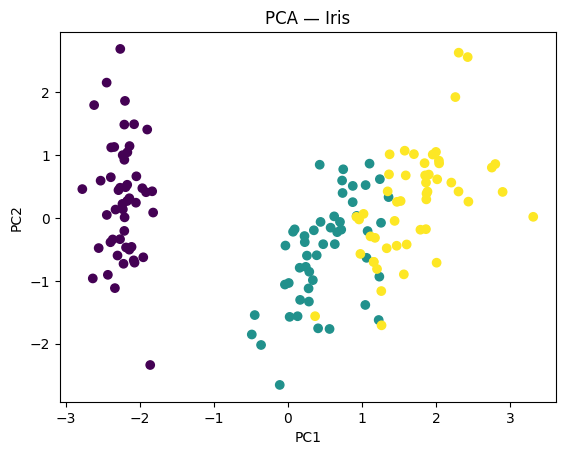

In [13]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_iris)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — Iris")
plt.show()

## LDA

In [14]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_iris, y_iris)

print("Original shape:", X_iris.shape)
print("Reduced shape:", X_lda.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


## LDA Visualization

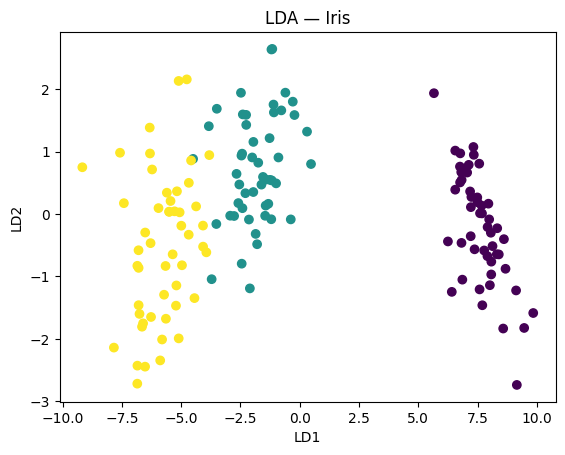

In [15]:
plt.scatter(X_lda[:,0], X_lda[:,1], c=y_iris)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA — Iris")
plt.show()

## Linear Regression

In [16]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2:", r2_score(y_test, pred))

MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R2: 0.4526027629719195


## Linear Regression — Actual vs Predicted

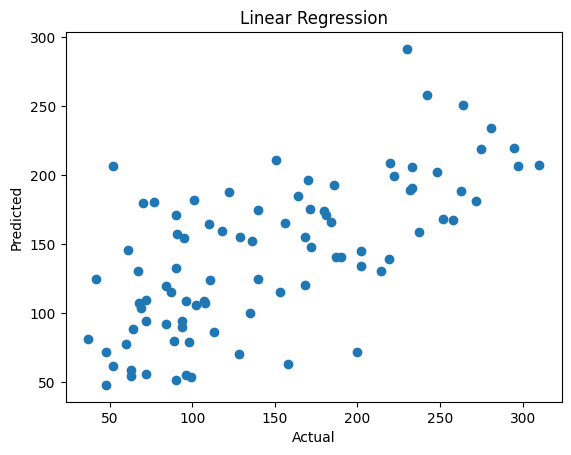

In [17]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

## Prepare Classification Dataset

In [18]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [19]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))
print("Probabilities:", model.predict_proba(X_test_scaled)[:5])

Accuracy: 0.9824561403508771
Probabilities: [[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


## Decision Tree

In [20]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9385964912280702


## Decision Tree Feature Importance

In [21]:
pd.Series(
    model.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False).head(10)

,0
worst radius,0.733548
worst concave points,0.122028
texture error,0.045785
worst texture,0.032319
worst concavity,0.017161
mean concave points,0.013327
area error,0.012704
mean texture,0.011846
worst symmetry,0.011282
mean area,0.000000


## Random Forest

In [22]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
pred = forest.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.956140350877193


## Random Forest Feature Importance

In [23]:
pd.Series(
    forest.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False).head(10)

,0
worst area,0.140016
worst concave points,0.129530
worst radius,0.097696
mean concave points,0.090885
worst perimeter,0.072226
mean perimeter,0.069574
mean radius,0.068676
mean concavity,0.057638
mean area,0.049172
worst concavity,0.034340


## KNN

In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.956140350877193


## SVM — Linear Kernel

In [25]:
svm = SVC(kernel="linear")
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9736842105263158


## SVM — RBF Kernel

In [26]:
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9824561403508771


## Naive Bayes

In [27]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9385964912280702


## Compare Classification Models

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append([name, accuracy_score(y_test, pred)])

pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(
    "Accuracy", ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.982456
4,SVM,0.982456
3,KNN,0.956140
2,Random Forest,0.956140
1,Decision Tree,0.938596
5,Naive Bayes,0.938596
